# Nozzle-dissipation comparison: all runs and snapshots

This notebook analyses the restartable outputs from `nozzle-dissipation-all.py`. Every point uses the updated nozzle selection: no stellar mask, longitude centred on the maximum-dissipation-density cell, an angular half-width of 4.5 degrees, and radius below 1100 Schwarzschild radii. Exactly the same selected cells are used for every diagnostic.

The two rate curves compare normalization by the actual summed kinetic energy with the notebook's local-velocity proxy.

In [1]:
import csv
from pathlib import Path

import numpy as np

import dev  # repository imports and plotting style; import before pyplot
import matplotlib.pyplot as plt
from dev.datapaths import DATAPATHS

RESULT_ROOT = Path('/home/hey4/rich_tde/data/processed/NozzleDissipationComparison/max-dissipation-nozzle')
ANALYSIS_ROOT = RESULT_ROOT / 'analysis'
FIGURE_ROOT = ANALYSIS_ROOT / 'figures'
ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

RUNS = ('1e4', '1e5', '1e6')
RUN_LABELS = {'1e4': r'$10^4\,M_\odot$', '1e5': r'$10^5\,M_\odot$', '1e6': r'$10^6\,M_\odot$'}
RUN_COLORS = {'1e4': 'C0', '1e5': 'C1', '1e6': 'C2'}

Matplotlib is building the font cache; this may take a moment.


## Load results and check completeness

In [2]:
def python_scalar(value):
    value = np.asarray(value)
    return value.item() if value.ndim == 0 else value


def load_result(path):
    with np.load(path) as data:
        row = {key: python_scalar(data[key]) for key in data.files}
    row['result_path'] = str(path)
    return row


rows = []
for run in RUNS:
    paths = sorted((RESULT_ROOT / run).glob('nozzle_dissipation_snap_*.npz'))
    rows.extend(load_result(path) for path in paths)
rows.sort(key=lambda row: (row['run'], row['time_tfb'], row['snapnum']))

for run in RUNS:
    expected_snapnums, _ = DATAPATHS(run)
    found = {int(row['snapnum']) for row in rows if row['run'] == run}
    missing = sorted(set(expected_snapnums) - found)
    invalid = [row for row in rows if row['run'] == run and not row.get('selection_valid', True)]
    print(f'{run}: {len(found)}/{len(expected_snapnums)} snapshots', end='')
    print(' (complete)' if not missing else f'; missing {len(missing)}: {missing[:12]}', end='')
    print(f'; empty selections: {len(invalid)}')

assert rows, f'No results found below {RESULT_ROOT}'

1e4: 152/152 snapshots (complete); empty selections: 0
1e5: 162/162 snapshots (complete); empty selections: 0
1e6: 842/842 snapshots (complete); empty selections: 76


In [3]:
summary_path = ANALYSIS_ROOT / 'nozzle-dissipation-all-summary.csv'
columns = list(dict.fromkeys(key for row in rows for key in row))
with summary_path.open('w', newline='', encoding='utf-8') as stream:
    writer = csv.DictWriter(stream, fieldnames=columns)
    writer.writeheader()
    writer.writerows(rows)
print(f'Saved {summary_path} ({len(rows)} rows)')

Saved /home/hey4/rich_tde/data/processed/NozzleDissipationComparison/max-dissipation-nozzle/analysis/nozzle-dissipation-all-summary.csv (1156 rows)


## Diagnostics on the shared nozzle selection

Saved /home/hey4/rich_tde/data/processed/NozzleDissipationComparison/max-dissipation-nozzle/analysis/figures/nozzle-diagnostics-vs-time.png


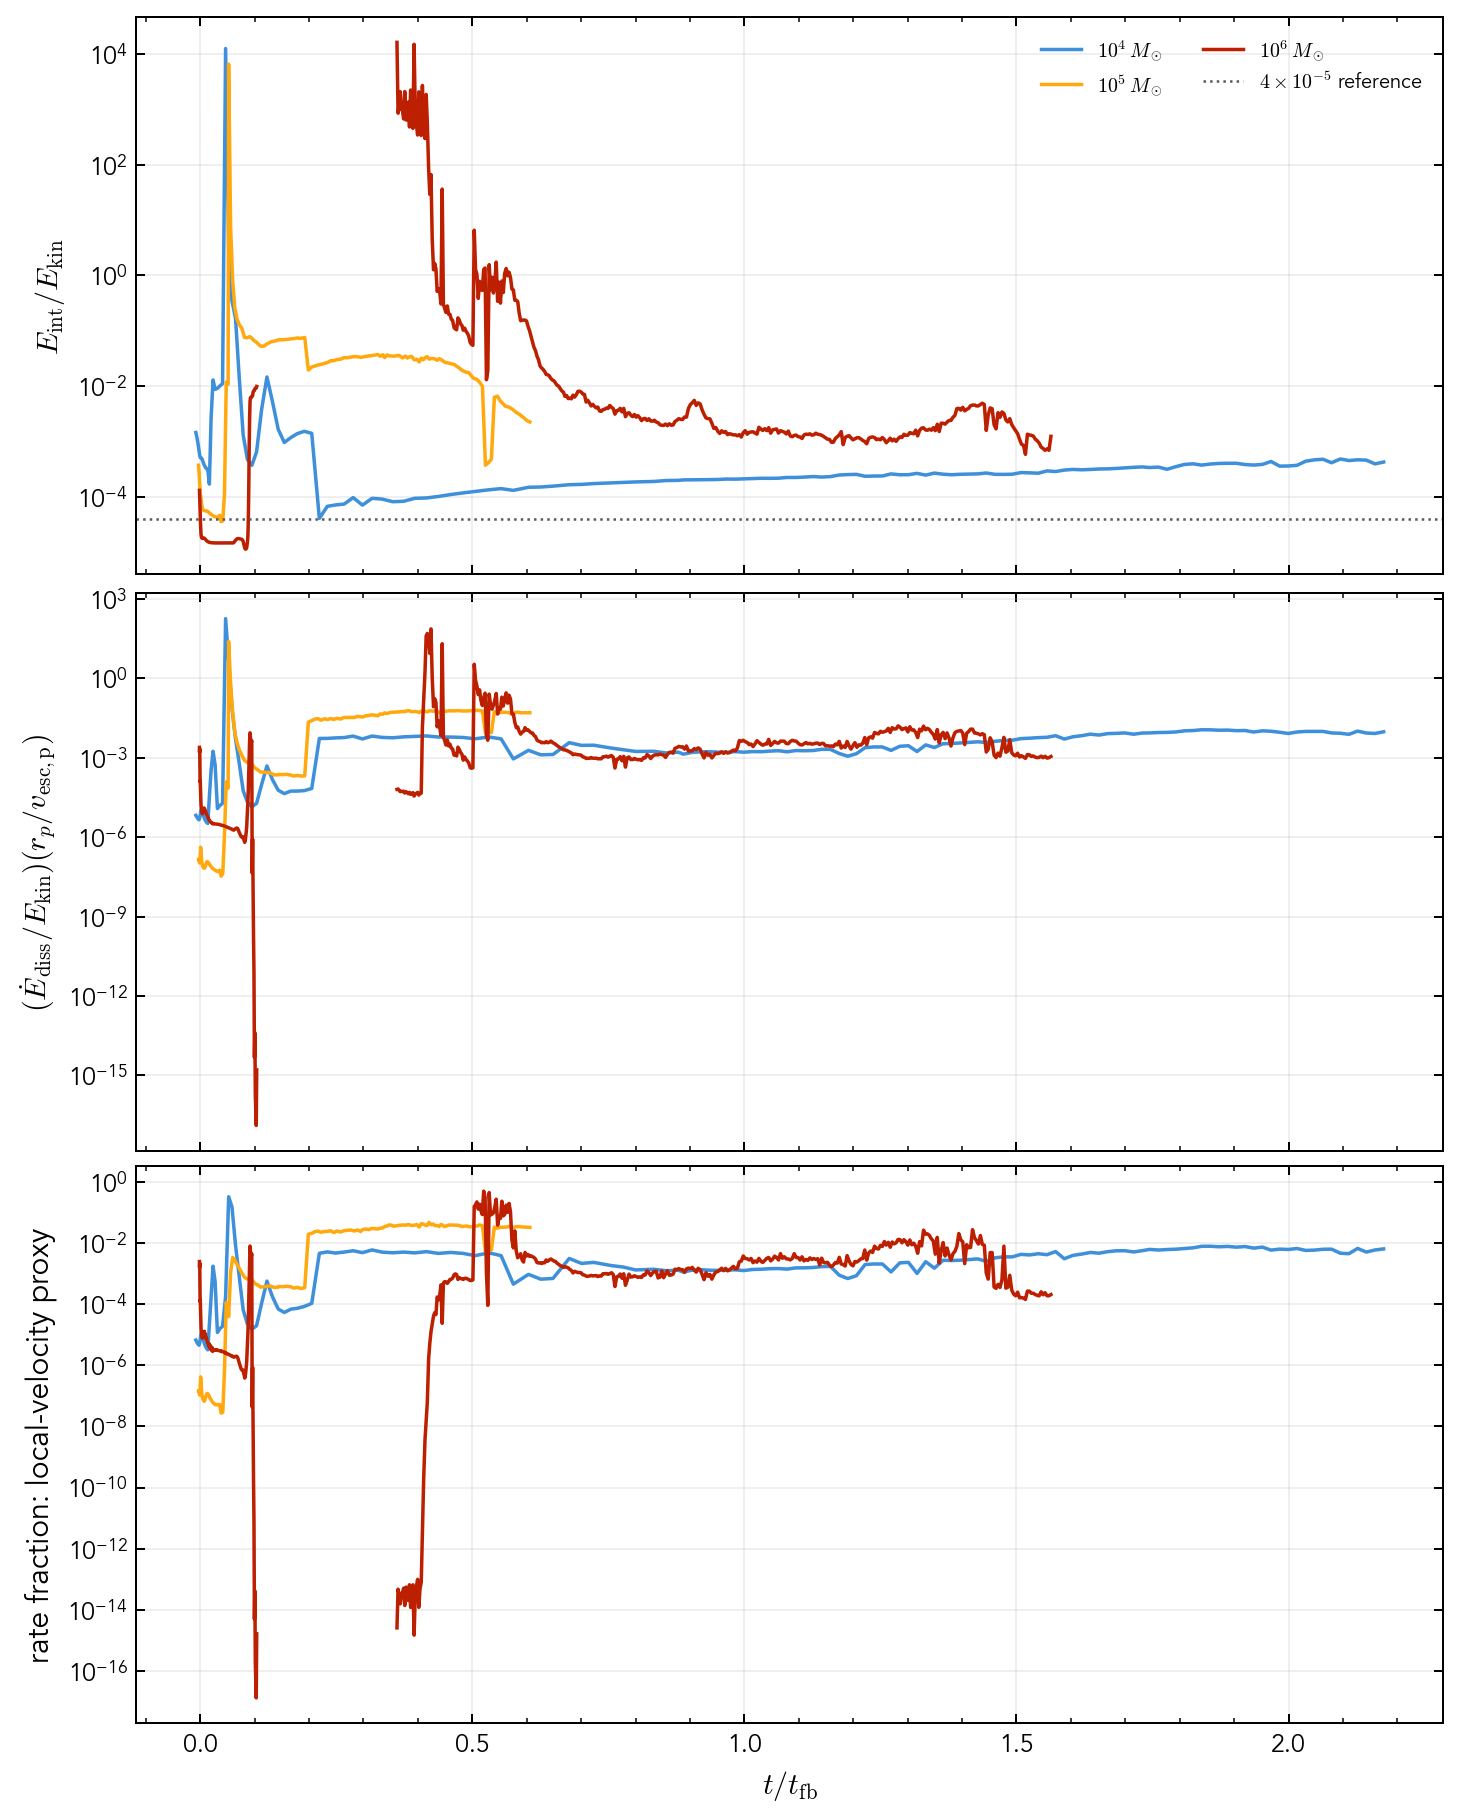

In [4]:
def run_rows(run):
    return [row for row in rows if row['run'] == run]


def positive(values):
    values = np.asarray(values, dtype=float)
    return np.where(values > 0, values, np.nan)


diagnostics = (
    ('nozzle_internal_over_kinetic', r'$E_{\rm int}/E_{\rm kin}$'),
    ('nozzle_rate_fraction_summed_kinetic', r'$(\dot E_{\rm diss}/E_{\rm kin})(r_p/v_{\rm esc,p})$'),
    ('nozzle_rate_fraction_local_velocity', 'rate fraction: local-velocity proxy'),
)
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True, dpi=180, constrained_layout=True)
for ax, (key, ylabel) in zip(axes, diagnostics):
    for run in RUNS:
        selected = run_rows(run)
        time = [row['time_tfb'] for row in selected]
        ax.plot(time, positive([row[key] for row in selected]),
                color=RUN_COLORS[run], linewidth=1.4, label=RUN_LABELS[run])
    ax.set_yscale('log')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.2)
axes[0].axhline(4e-5, color='0.35', linestyle=':', linewidth=1, label=r'$4\times10^{-5}$ reference')
axes[0].legend(ncol=2, fontsize=8)
axes[-1].set_xlabel(r'$t/t_{\rm fb}$')
figure_path = FIGURE_ROOT / 'nozzle-diagnostics-vs-time.png'
fig.savefig(figure_path, bbox_inches='tight')
print(f'Saved {figure_path}')
plt.show()

## Direct comparison of accumulated and rate-based estimates

Their separation is physically meaningful: internal energy is accumulated and can be advected or cooled, whereas the dissipation diagnostic is instantaneous and is converted to an energy fraction using one pericentre crossing time.

Saved /home/hey4/rich_tde/data/processed/NozzleDissipationComparison/max-dissipation-nozzle/analysis/figures/nozzle-diagnostic-direct-comparison.png


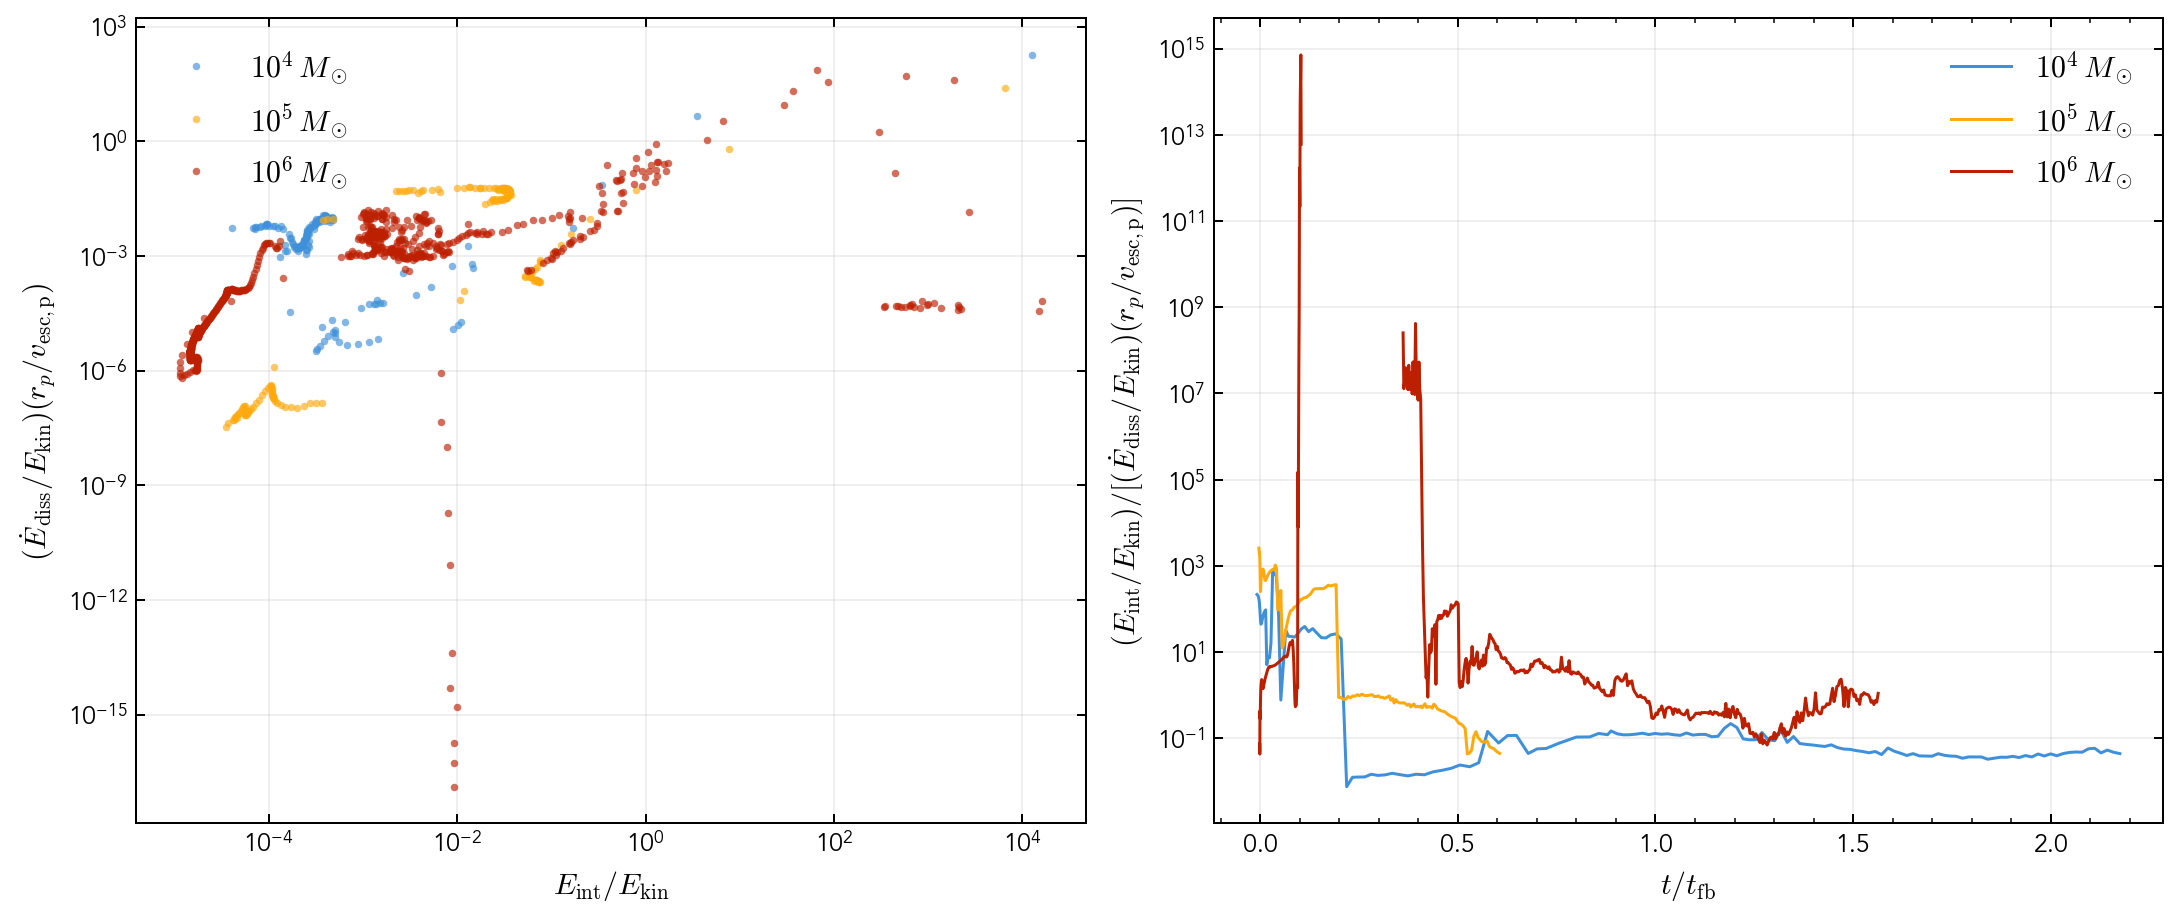

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=180, constrained_layout=True)
for run in RUNS:
    selected = run_rows(run)
    x = positive([row['nozzle_internal_over_kinetic'] for row in selected])
    y = positive([row['nozzle_rate_fraction_summed_kinetic'] for row in selected])
    y_local = positive([row['nozzle_rate_fraction_local_velocity'] for row in selected])
    axes[0].plot(x, y, '.', color=RUN_COLORS[run], alpha=0.65, label=RUN_LABELS[run])
    axes[0].plot(x, y_local, 'x', color=RUN_COLORS[run], alpha=0.45)
    axes[1].plot([row['time_tfb'] for row in selected], positive(x / y),
                 color=RUN_COLORS[run], linewidth=1.2, label=RUN_LABELS[run])
axes[0].set(xscale='log', yscale='log', xlabel=r'$E_{\rm int}/E_{\rm kin}$',
            ylabel=r'$(\dot E_{\rm diss}/E_{\rm kin})(r_p/v_{\rm esc,p})$')
axes[1].set(yscale='log', xlabel=r'$t/t_{\rm fb}$',
            ylabel=r'$(E_{\rm int}/E_{\rm kin}) / [(\dot E_{\rm diss}/E_{\rm kin})(r_p/v_{\rm esc,p})]$')
for ax in axes:
    ax.grid(alpha=0.2)
    ax.legend()
figure_path = FIGURE_ROOT / 'nozzle-diagnostic-direct-comparison.png'
fig.savefig(figure_path, bbox_inches='tight')
print(f'Saved {figure_path}')
plt.show()

## Selection diagnostics

These panels expose changes in the moving maximum-dissipation wedge, helping distinguish physical evolution from changes in its centre or contents.

Saved /home/hey4/rich_tde/data/processed/NozzleDissipationComparison/max-dissipation-nozzle/analysis/figures/nozzle-selection-diagnostics.png


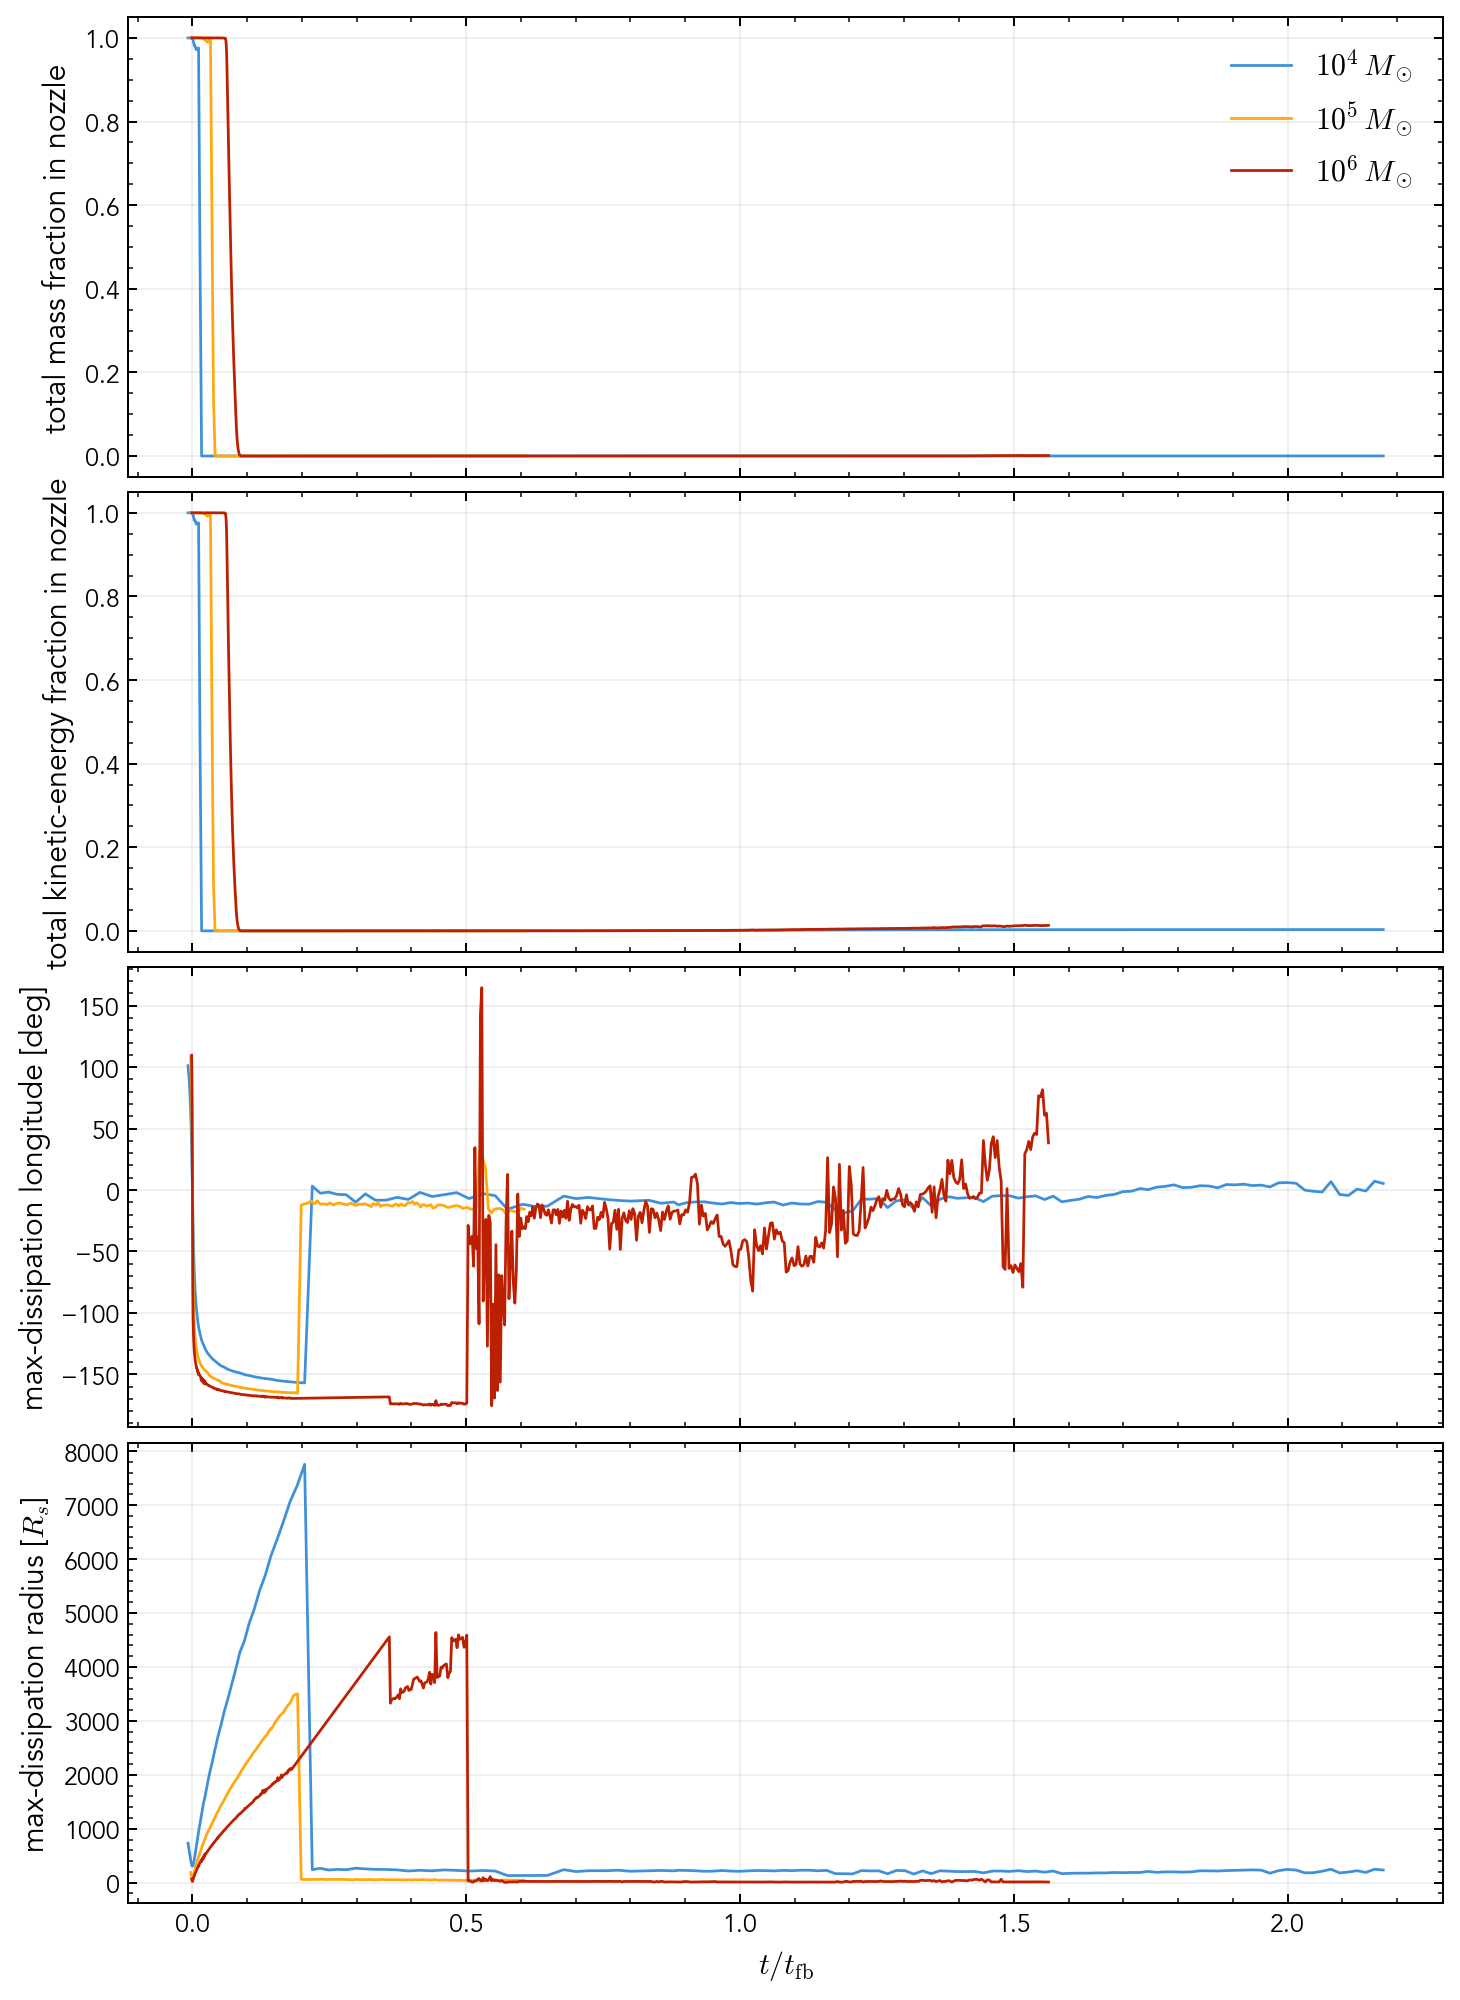

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(8, 11), sharex=True, dpi=180, constrained_layout=True)
selection_fields = (
    ('nozzle_mass_fraction', 'total mass fraction in nozzle'),
    ('nozzle_kinetic_fraction', 'total kinetic-energy fraction in nozzle'),
    ('selection_center_deg', 'max-dissipation longitude [deg]'),
    ('maximum_dissipation_radius_rs', r'max-dissipation radius [$R_s$]'),
)
for ax, (key, ylabel) in zip(axes, selection_fields):
    for run in RUNS:
        selected = run_rows(run)
        ax.plot([row['time_tfb'] for row in selected], [row[key] for row in selected],
                color=RUN_COLORS[run], linewidth=1.1, label=RUN_LABELS[run])
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.2)
axes[0].legend()
axes[-1].set_xlabel(r'$t/t_{\rm fb}$')
figure_path = FIGURE_ROOT / 'nozzle-selection-diagnostics.png'
fig.savefig(figure_path, bbox_inches='tight')
print(f'Saved {figure_path}')
plt.show()